# Task 1
Потрібно побудувати просту модель лінійної регресії на одній ознаці й отримати передбачення:
Завантажте вбудований датасет про діабет із бібліотеки scikit-learn.

* Виберіть одну ознаку (наприклад, індекс маси тіла — це ознака з індексом 2).
* Розділіть дані на навчальну і тестову вибірки (80/20).
* Побудуйте модель за допомогою класу LinearRegression з sklearn.linear_model.
* Отримайте передбачення на тестовій вибірці та виведіть перші 10 реальних і передбачених значень поруч.

In [8]:
from sklearn.datasets import load_diabetes
import pandas as pd
# print(dataset.DESCR)
diabetes = pd.DataFrame(dataset.data, columns=dataset.feature_names)
diabetes['Target'] = dataset.target
diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [11]:
data = diabetes[['bmi', 'Target']]
data.head()

,bmi,Target
0,0.061696,151.0
1,-0.051474,75.0
2,0.044451,141.0
3,-0.011595,206.0
4,-0.036385,135.0


In [12]:
import matplotlib.pyplot as plt

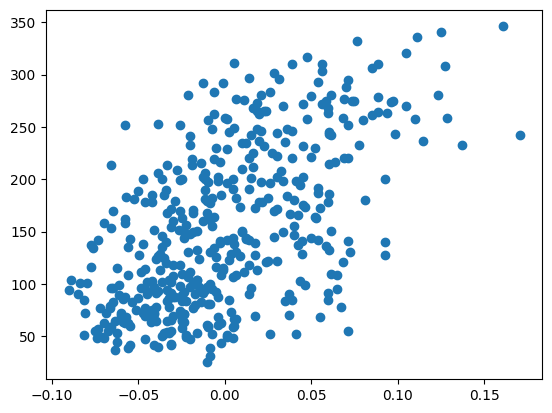

In [13]:
fig, ax = plt.subplots()
ax.plot(data['bmi'], data['Target'], 'o')
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(
    data['bmi'].array.reshape(-1, 1),
    data['Target'].array,
    test_size = 0.2,
    random_state = 0
)
print(ytest)

<NumpyExtensionArray>
[321.0, 215.0, 127.0,  64.0, 175.0, 275.0, 179.0, 232.0, 142.0,  99.0, 252.0,
 174.0, 129.0,  74.0, 264.0,  49.0,  86.0,  75.0, 101.0, 155.0, 170.0, 276.0,
 110.0, 136.0,  68.0, 128.0, 103.0,  93.0, 191.0, 196.0, 217.0, 181.0, 168.0,
 200.0, 219.0, 281.0, 151.0, 257.0,  49.0, 198.0,  96.0, 179.0,  95.0, 198.0,
 244.0,  89.0, 214.0, 182.0,  84.0, 270.0, 156.0, 138.0, 113.0, 131.0, 195.0,
 171.0, 122.0,  61.0, 230.0, 235.0,  52.0, 121.0, 144.0, 107.0, 132.0, 302.0,
  53.0, 317.0, 137.0,  57.0,  98.0, 170.0,  88.0,  90.0,  67.0, 163.0, 104.0,
 186.0, 180.0, 283.0, 141.0, 150.0,  47.0, 297.0, 104.0,  49.0, 103.0, 142.0,
  59.0]
Length: 89, dtype: float64


In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(xtrain, ytrain)
print(f'For formula y = ax + b, have: a={model.coef_[0]}, b={model.intercept_}')

ypred = model.predict(xtest)
for i in range(10):
    x = xtest[i][0]
    print(
        f'x={x:.3f}, valid value {ytest[i]:.1f}, provided for {ypred[i]:.1f}, ' +
        f'control: {model.coef_[0] * x + model.intercept_:.1f}'
    )

For formula y = ax + b, have: a=981.6554361411928, b=152.28824927379569
x=0.105, valid value 321.0, provided for 255.2, control: 255.2
x=0.061, valid value 215.0, provided for 211.8, control: 211.8
x=0.009, valid value 127.0, provided for 161.0, control: 161.0
x=-0.023, valid value 64.0, provided for 129.3, control: 129.3
x=0.046, valid value 175.0, provided for 197.0, control: 197.0
x=0.097, valid value 275.0, provided for 247.8, control: 247.8
x=-0.029, valid value 179.0, provided for 124.0, control: 124.0
x=0.023, valid value 232.0, provided for 174.8, control: 174.8
x=0.054, valid value 142.0, provided for 205.4, control: 205.4
x=0.047, valid value 99.0, provided for 198.0, control: 198.0


# Task 2
Необхідно візуально показати, як модель описує дані:
Використовуйте ті самі дані та модель, що в завданні 1.

* Побудуйте scatter-графік: по осі X — значення ознаки, по осі Y — реальні значення цільової змінної.
* Поверх точок побудуйте пряму регресії (передбачення моделі).
* Додайте підписи осей і легенду.

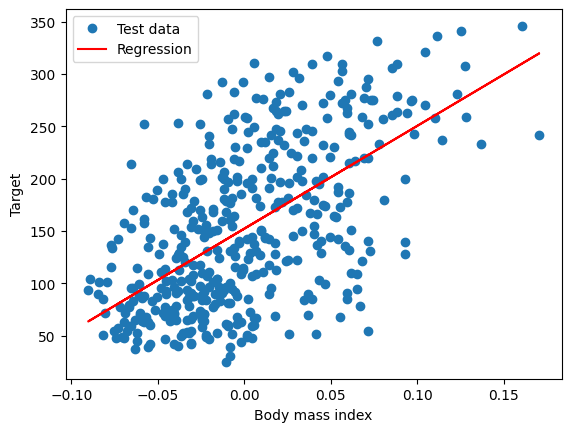

In [37]:
data['pred'] = model.predict(data['bmi'].array.reshape(-1, 1))
fig, ax = plt.subplots()
ax.plot(data['bmi'], data['Target'], 'o', label='Test data')
ax.plot(data['bmi'], data['pred'], 'r-', label='Regression')

ax.set_xlabel('Body mass index')
ax.set_ylabel('Target')
ax.legend()

plt.show()

# Task 3
Потрібно виміряти якість побудованої моделі за допомогою метрик регресії:
Використовуйте тестову вибірку із завдання 1.

* Обчисліть метрики за допомогою функцій з sklearn.metrics:

    * mean_absolute_error — MAE (Mean Absolute Error);
    * mean_squared_error — MSE (Mean Squared Error);

* r2_score — R² (коефіцієнт детермінації).
* Оформіть результати в таблиці:

In [41]:
import sklearn.metrics as sm
from IPython.display import Markdown as md

md("|Metric|Value|\n|-|-|\n|MAE (Mean Absolute Error)|%f|\n|MSE (Mean Squared Error)|%f|\n|R^2 (determination coefficient)|%f|" %(
    sm.mean_absolute_error(data['pred'], data['Target']),
    sm.mean_squared_error(data['pred'], data['Target']),
    sm.r2_score(data['pred'], data['Target'])
))

|Metric|Value|
|-|-|
|MAE (Mean Absolute Error)|51.648043|
|MSE (Mean Squared Error)|3892.829270|
|R^2 (determination coefficient)|-0.785540|

# Task 4
Потрібно реалізувати простий варіант градієнтного спуску і порівняти його результат із моделлю, побудованою за допомогою класу LinearRegression.
Використовуйте одну ознаку з датасету про діабет і цільову змінну.

* Реалізуйте функцію навчання лінійної регресії методом градієнтного спуску
* Навчіть модель і отримайте коефіцієнти (w, b).
* Порівняйте MAE вашої реалізації та результату моделі LinearRegression.

In [43]:
from sklearn.linear_model import SGDClassifier
data['predSGD'] = sgd_model.predict(data['bmi'].array.reshape(-1, 1))
sgd_model = SGDClassifier()

sgd_model.fit(xtrain, ytrain)

ypred = sgd_model.predict(xtest)
for i in range(10):
    x = xtest[i][0]
    print(
        f'x={x:.3f}, valid value {ytest[i]:.1f}, provided for {ypred[i]:.1f}, '
    )

x=0.105, valid value 321.0, provided for 221.0, 
x=0.061, valid value 215.0, provided for 221.0, 
x=0.009, valid value 127.0, provided for 75.0, 
x=-0.023, valid value 64.0, provided for 75.0, 
x=0.046, valid value 175.0, provided for 221.0, 
x=0.097, valid value 275.0, provided for 221.0, 
x=-0.029, valid value 179.0, provided for 75.0, 
x=0.023, valid value 232.0, provided for 75.0, 
x=0.054, valid value 142.0, provided for 221.0, 
x=0.047, valid value 99.0, provided for 221.0, 


In [49]:
md("|Metric|Liner Value|SGD Value|\n|-|-|-|\n|MAE (Mean Absolute Error)|%f|%f|\n|MSE (Mean Squared Error)|%f|%f|\n|R^2 (determination coefficient)|%f|%f|" %(
    sm.mean_absolute_error(data['pred'], data['Target']), sm.mean_absolute_error(data['predSGD'], data['Target']),
    sm.mean_squared_error(data['pred'], data['Target']), sm.mean_squared_error(data['predSGD'], data['Target']),
    sm.r2_score(data['pred'], data['Target']), sm.r2_score(data['predSGD'], data['Target'])
))

|Metric|Liner Value|SGD Value|
|-|-|-|
|MAE (Mean Absolute Error)|51.648043|110.319005|
|MSE (Mean Squared Error)|3892.829270|18059.269231|
|R^2 (determination coefficient)|-0.785540|0.000000|